# 2. Exploration — Enquêtes (`employee_survey_data.csv` & `manager_survey_data.csv`)

Ce notebook explore les deux fichiers d'enquête :
- **`employee_survey_data.csv`** : enquête qualité de vie au travail (juin 2015, réponse non obligatoire)
- **`manager_survey_data.csv`** : évaluation de chaque employé par son manager (février 2015)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

---
## 2.1 Enquête employé (`employee_survey_data.csv`)

Questionnaire soumis en juin 2015. Les employés devaient noter de 1 à 4 :
- `EnvironmentSatisfaction` : satisfaction de l'environnement de travail
- `JobSatisfaction` : satisfaction du travail
- `WorkLifeBalance` : équilibre vie pro / vie perso

`NA` = l'employé n'a pas répondu à la question.

In [2]:
df_emp = pd.read_csv("data/employee_survey_data.csv")
print(f"Dimensions : {df_emp.shape}")
df_emp.head()

Dimensions : (4410, 4)


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0


In [3]:
df_emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB


In [4]:
# Valeurs manquantes
missing_emp = df_emp.isnull().sum()
print("Valeurs manquantes :")
print(missing_emp)
print(f"\nPourcentage de lignes avec au moins un NA : "
      f"{df_emp.isnull().any(axis=1).mean() * 100:.1f}%")

Valeurs manquantes :
EmployeeID                  0
EnvironmentSatisfaction    25
JobSatisfaction            20
WorkLifeBalance            38
dtype: int64

Pourcentage de lignes avec au moins un NA : 1.9%


In [5]:
# Vérification de la clé EmployeeID
print(f"EmployeeID uniques : {df_emp['EmployeeID'].nunique()} / {len(df_emp)}")
print(f"Plage : [{df_emp['EmployeeID'].min()}, {df_emp['EmployeeID'].max()}]")

EmployeeID uniques : 4410 / 4410
Plage : [1, 4410]


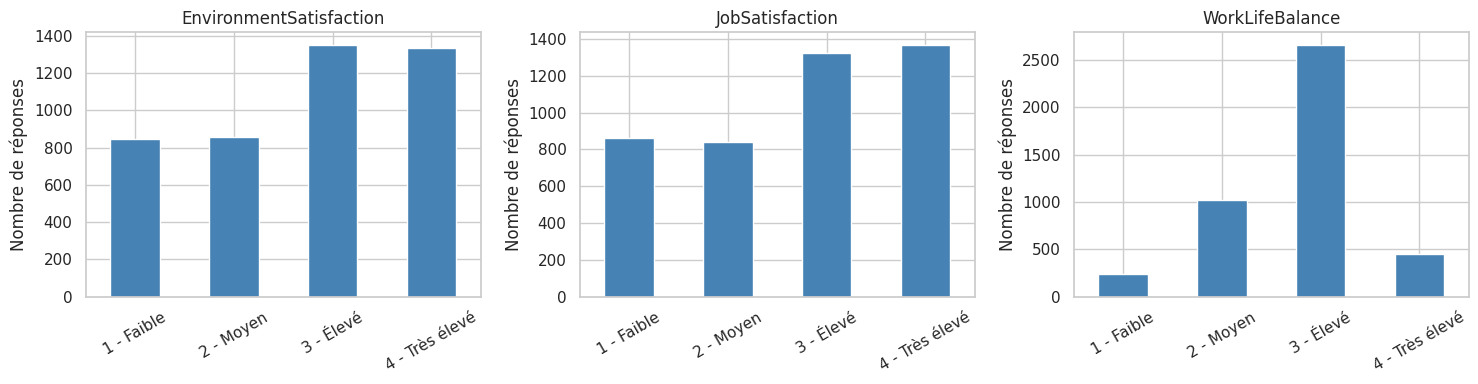

In [6]:
# Distribution des réponses
survey_cols = ["EnvironmentSatisfaction", "JobSatisfaction", "WorkLifeBalance"]
labels_map = {1: "1 - Faible", 2: "2 - Moyen", 3: "3 - Élevé", 4: "4 - Très élevé"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, survey_cols):
    counts = df_emp[col].value_counts().sort_index()
    counts.index = [labels_map.get(i, i) for i in counts.index]
    counts.plot.bar(ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_ylabel("Nombre de réponses")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [7]:
df_emp[survey_cols].describe()

,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
count,4385.000000,4390.000000,4372.000000
mean,2.723603,2.728246,2.761436
std,1.092756,1.101253,0.706245
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000
75%,4.000000,4.000000,3.000000
max,4.000000,4.000000,4.000000


---
## 2.2 Évaluation manager (`manager_survey_data.csv`)

Dernière évaluation de chaque employé par son manager, réalisée en février 2015 :
- `JobInvolvement` : implication au travail (1=Faible → 4=Très importante)
- `PerformanceRating` : niveau de performance (1=Faible → 4=Au-delà des attentes)

In [8]:
df_mgr = pd.read_csv("data/manager_survey_data.csv")
print(f"Dimensions : {df_mgr.shape}")
df_mgr.head()

Dimensions : (4410, 3)


,EmployeeID,JobInvolvement,PerformanceRating
0,1,3,3
1,2,2,4
2,3,3,3
3,4,2,3
4,5,3,3


In [9]:
df_mgr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


In [10]:
# Valeurs manquantes
print("Valeurs manquantes :")
print(df_mgr.isnull().sum())

Valeurs manquantes :
EmployeeID           0
JobInvolvement       0
PerformanceRating    0
dtype: int64


In [11]:
# Vérification de la clé EmployeeID
print(f"EmployeeID uniques : {df_mgr['EmployeeID'].nunique()} / {len(df_mgr)}")
print(f"Plage : [{df_mgr['EmployeeID'].min()}, {df_mgr['EmployeeID'].max()}]")

EmployeeID uniques : 4410 / 4410
Plage : [1, 4410]


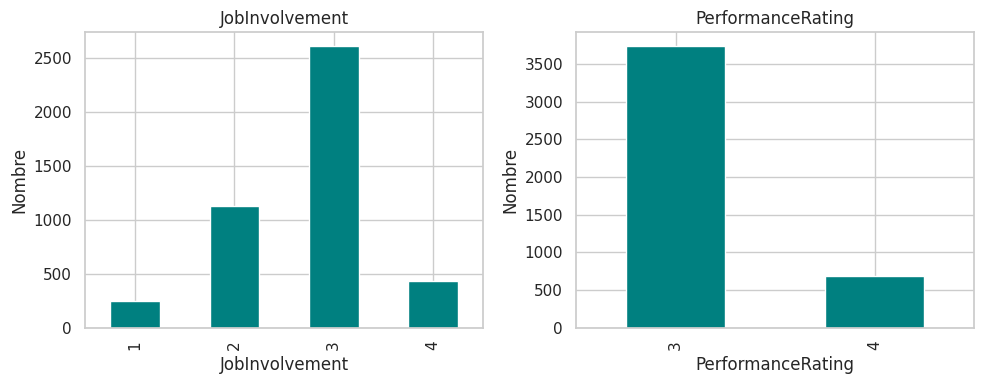

In [12]:
# Distribution des évaluations
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ["JobInvolvement", "PerformanceRating"]):
    counts = df_mgr[col].value_counts().sort_index()
    counts.plot.bar(ax=ax, color="teal")
    ax.set_title(col)
    ax.set_ylabel("Nombre")
plt.tight_layout()
plt.show()

In [13]:
df_mgr[["JobInvolvement", "PerformanceRating"]].describe()

,JobInvolvement,PerformanceRating
count,4410.000000,4410.000000
mean,2.729932,3.153741
std,0.711400,0.360742
min,1.000000,3.000000
25%,2.000000,3.000000
50%,3.000000,3.000000
75%,3.000000,3.000000
max,4.000000,4.000000


## 2.3 Croisement des deux enquêtes

Vérifions que les deux fichiers couvrent les mêmes employés.

In [14]:
emp_ids = set(df_emp["EmployeeID"])
mgr_ids = set(df_mgr["EmployeeID"])

print(f"Employés dans employee_survey : {len(emp_ids)}")
print(f"Employés dans manager_survey  : {len(mgr_ids)}")
print(f"Intersection                  : {len(emp_ids & mgr_ids)}")
print(f"Uniquement dans employee_survey : {len(emp_ids - mgr_ids)}")
print(f"Uniquement dans manager_survey  : {len(mgr_ids - emp_ids)}")

Employés dans employee_survey : 4410
Employés dans manager_survey  : 4410
Intersection                  : 4410
Uniquement dans employee_survey : 0
Uniquement dans manager_survey  : 0


Après jointure interne sur EmployeeID : 4410 lignes


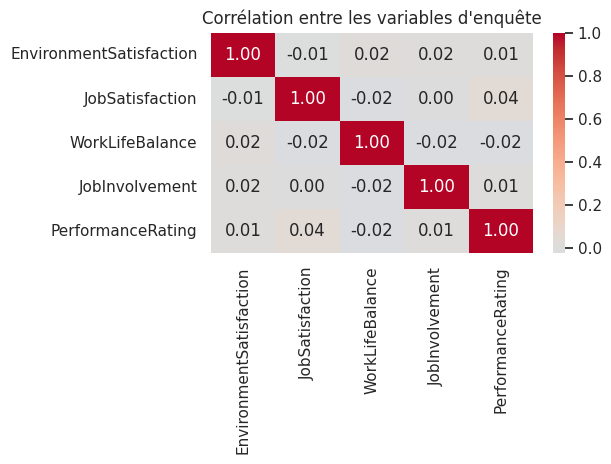

In [15]:
# Matrice de corrélation entre toutes les variables d'enquête
df_surveys = df_emp.merge(df_mgr, on="EmployeeID", how="inner")
print(f"Après jointure interne sur EmployeeID : {len(df_surveys)} lignes")

corr = df_surveys.drop(columns="EmployeeID").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Corrélation entre les variables d'enquête")
plt.tight_layout()
plt.show()